# Off-by-one envelope explorer

Interactively compare, for each monoisotope **off-by-one** miss, the real observed MS1 isotope
envelope against the two competing interpretations:

- **FlashLFQ (ref)** — averagine anchored at the MetaMorpheus/FlashLFQ monoisotopic mass (`k=0`).
- **Pipeline** — averagine anchored where our untargeted detector placed the mono (`k = reported_k`).

Whichever template hugs the gray observed centroids is where the monoisotope really is.

**Data** comes from `obo_meta.tsv`, `obo_series.tsv`, `obo_scans.tsv` in this folder, written by
`rust/flashlfq-core/examples/obo_envelope_probe.rs`:

```
cargo build --release --example obo_envelope_probe
EXPORT_DIR=analysis  ./target/release/examples/obo_envelope_probe   # (set env, then run the exe)
```

To explore **new** peptides, edit the `targets` array in that example and re-run with `EXPORT_DIR`.

Needs only `numpy` + `matplotlib` + stdlib `csv`. `ipywidgets` is used for sliders if available.


In [11]:
import csv, os
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = os.path.dirname(os.path.abspath("__file__")) if "__file__" in globals() else os.getcwd()
# When run from the repo root or the analysis dir, fall back to finding the TSVs next to this nb.
for cand in (DATA_DIR, os.path.join(DATA_DIR, "analysis"), "."):
    if os.path.exists(os.path.join(cand, "obo_meta.tsv")):
        DATA_DIR = cand
        break
print("data dir:", DATA_DIR)

meta, order = {}, []
with open(os.path.join(DATA_DIR, "obo_meta.tsv"), newline="") as f:
    for row in csv.DictReader(f, delimiter="\t"):
        order.append(row["case"])
        meta[row["case"]] = {k: (int(row[k]) if k in ("z", "reported_k") else float(row[k]))
                             for k in ("ref_mono","z","rt","pk_mz","reported_k","spacing","mono_mz")}

series = defaultdict(lambda: defaultdict(list))     # case -> series -> [(mz, inten)]
with open(os.path.join(DATA_DIR, "obo_series.tsv"), newline="") as f:
    for row in csv.DictReader(f, delimiter="\t"):
        series[row["case"]][row["series"]].append((float(row["mz"]), float(row["intensity"])))

scans = defaultdict(lambda: defaultdict(list))      # case -> scan_offset -> [(mz, inten)]
scan_rt = defaultdict(dict)                          # case -> scan_offset -> rt
with open(os.path.join(DATA_DIR, "obo_scans.tsv"), newline="") as f:
    for row in csv.DictReader(f, delimiter="\t"):
        off = int(row["scan_offset"])
        scans[row["case"]][off].append((float(row["mz"]), float(row["intensity"])))
        scan_rt[row["case"]][off] = float(row["rt"])

order

data dir: f:\flashlfq-rust\analysis


['00_VGDANPALQK_z1',
 '01_YENEVALR_z2',
 '02_VGDANPALQK_z2',
 '03_VGDANPALQK_z2',
 '04_VLDELTLTK_z2',
 '05_SLIGRSDLNGK_z2',
 '06_FSSSSGYGGGSSR_z2',
 '07_HVGDLGNVTADK_z2',
 '08_LLEACTFHKP_z2',
 '09_GTFAALSELHCDK_z2',
 '10_SQYEQLAEQNRK_z2',
 '11_TAGWNIPMGLLYSK_z2',
 '12_YNSLTINNDITLLK_z2',
 '13_SCAAAGTECLISGWGNTK_z2',
 '14_SVTDCTSNFCLFQSNSK_z2',
 '15_YAAELHLVHWNTK_z3',
 '16_KYAAELHLVHWNTK_z3',
 '17_NKLNDLEDALQQAKEDLAR_z3',
 '18_AVVQDPALKPLALVYGEATSR_z3',
 '19_TSQNSELNNMQDLVEDYKK_z3',
 '20_RMVNNGHSFNVEYDDSQDK_z3',
 '21_LGEHNIDVLEGNEQFINAAK_z3',
 '22_IITHPNFNGNTLDNDIMLIK_z3',
 '23_AVVQDPALKPLALVYGEATSR_z3',
 '24_GGGGGGYGSGGSSYGSGGGSYG_z3',
 '25_MVNNGHSFNVEYDDSQDKAVLK_z3',
 '26_HTGPGILSMANAGPNTNGSQFF_z3',
 '27_HTGPGILSMANAGPNTNGSQFF_z3',
 '28_TLNFNAEGEPELLMLANWRPAQ_z3',
 '29_TLNFNAEGEPELLMLANWRPAQ_z3',
 '30_TLNFNAEGEPELLMLANWRPAQ_z3',
 '31_NGQPESEDKYGTTPPQLDADSS_z3',
 '32_TLNFNAEGEPELLMLANWRPAQ_z3',
 '33_DSCQGDSGGPVVCNGQLQGIVS_z3',
 '34_DSCQGDSGGPVVCNGQLQGIVS_z3',
 '35_HNGPEHWHKDFPIANGER|HN

## A self-contained averagine model

So you can overlay a template at **any** shift (not just the three the Rust probe exported), here is a
small pure-Python averagine: pick the averagine composition for a target mass, then compute its
isotope envelope by convolving the elemental isotope patterns. It reproduces the *shape* (and the
mode-shift for heavy peptides) of the Rust `deconvolution::averagine_*` model; a validation cell below
overlays it on the exported Rust templates so you can confirm.

In [2]:
PROTON = 1.007276466

# Monoisotopic masses and isotope-abundance vectors (probability by neutron offset from monoisotope).
_EL = {
    "C": (12.0,            [0.9893, 0.0107]),
    "H": (1.0078250319,    [0.999885, 0.000115]),
    "N": (14.0030740052,   [0.99636, 0.00364]),
    "O": (15.9949146221,   [0.99757, 0.00038, 0.00205]),
    "S": (31.97207069,     [0.9499, 0.0075, 0.0425, 0.0, 0.0001]),
}
# Averagine residue coefficients per unit multiplier (mzLib / deconvolution.rs magic numbers).
_AVG = {"C": 4.9384, "H": 7.7583, "O": 1.4773, "N": 1.3577, "S": 0.0417}
_RES_MASS = sum(_AVG[e] * _EL[e][0] for e in _AVG)   # ~111.05 Da per multiplier

def _conv_pow(base, n, maxlen=18):
    # Isotope pattern of n identical atoms: base convolved n times, truncated.
    dist = np.array([1.0])
    b = np.array(base)
    for _ in range(int(n)):
        dist = np.convolve(dist, b)[:maxlen]
    return dist

def averagine_weights(mono_mass, maxlen=16):
    # Per-isotope-index weights (index 0 = monoisotope) for a peptide of the given mono mass,
    # normalised so the max weight is 1.0.
    mult = max(mono_mass / _RES_MASS, 0.5)
    dist = np.array([1.0])
    for e, coeff in _AVG.items():
        n = round(coeff * mult)
        if n <= 0:
            continue
        dist = np.convolve(dist, _conv_pow(_EL[e][1], n, maxlen))[:maxlen]
    dist = dist[:maxlen]
    return dist / dist.max()

def to_mz(mass, z):
    return mass / z + PROTON

def template(mono_mass, z, kshift=0, maxlen=14, min_w=1e-3):
    # (mz, weight) teeth for the averagine envelope of mono_mass shifted by kshift 13C units, at
    # charge z. Weights max-normalised to 1.0; trailing teeth below min_w dropped.
    C13 = 1.0033548381
    anchor = mono_mass + kshift * C13
    w = averagine_weights(anchor, maxlen)
    # drop the descending tail below min_w (keep through the mode)
    mode = int(np.argmax(w))
    end = len(w)
    while end > mode + 1 and w[end-1] < min_w:
        end -= 1
    w = w[:end]
    mz = [to_mz(anchor + k * C13, z) for k in range(len(w))]
    return list(zip(mz, w))

print("averagine residue mass ~ %.3f Da/multiplier" % _RES_MASS)

averagine residue mass ~ 111.054 Da/multiplier


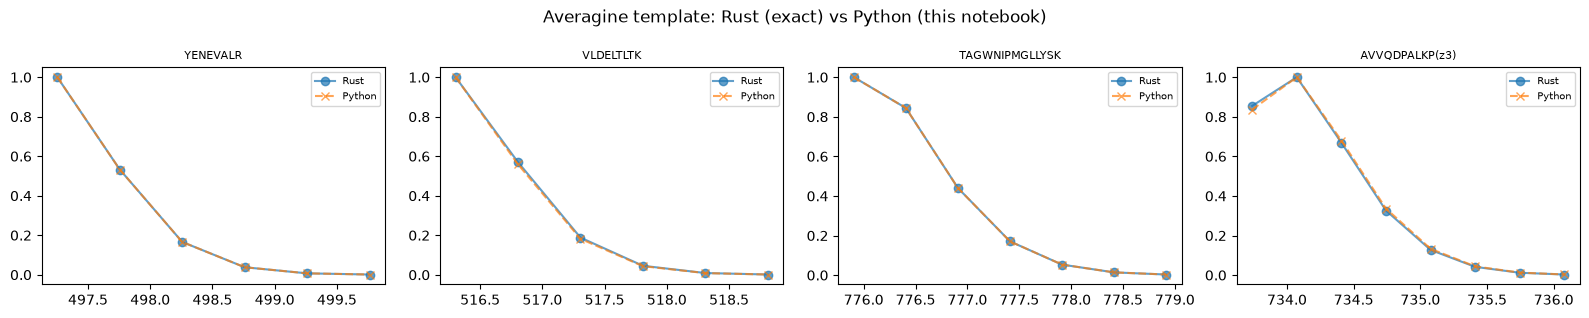

In [3]:
# Validation: our Python averagine vs the exact Rust templates the probe exported (should match shape).
fig, axes = plt.subplots(1, len(order), figsize=(4*len(order), 3.2))
for ax, case in zip(np.atleast_1d(axes), order):
    m = meta[case]
    rust = sorted(series[case]["avg_mono"])
    py = template(m["ref_mono"], m["z"], 0)
    ax.plot([p[0] for p in rust], [p[1] for p in rust], "o-", label="Rust", alpha=.7)
    ax.plot([p[0] for p in py], [p[1] for p in py], "x--", label="Python", alpha=.7)
    ax.set_title(case, fontsize=8); ax.legend(fontsize=7)
fig.suptitle("Averagine template: Rust (exact) vs Python (this notebook)"); fig.tight_layout()

In [64]:
random_selection = np.random.randint(0, len(order), size=4)
picked = [order[i] for i in random_selection]
picked

['05_SLIGRSDLNGK_z2',
 '38_MVNNGHSFNVEYDDSQDKAVLK_z4',
 '10_SQYEQLAEQNRK_z2',
 '07_HVGDLGNVTADK_z2']

## Per-case: observed envelope vs FlashLFQ vs pipeline

`plot_case(case, observed='observed_composite', extra_shifts=())` — set `observed` to
`'observed_apex'` for the single apex scan, or pass `extra_shifts=[+2, -2]` to overlay more anchors.

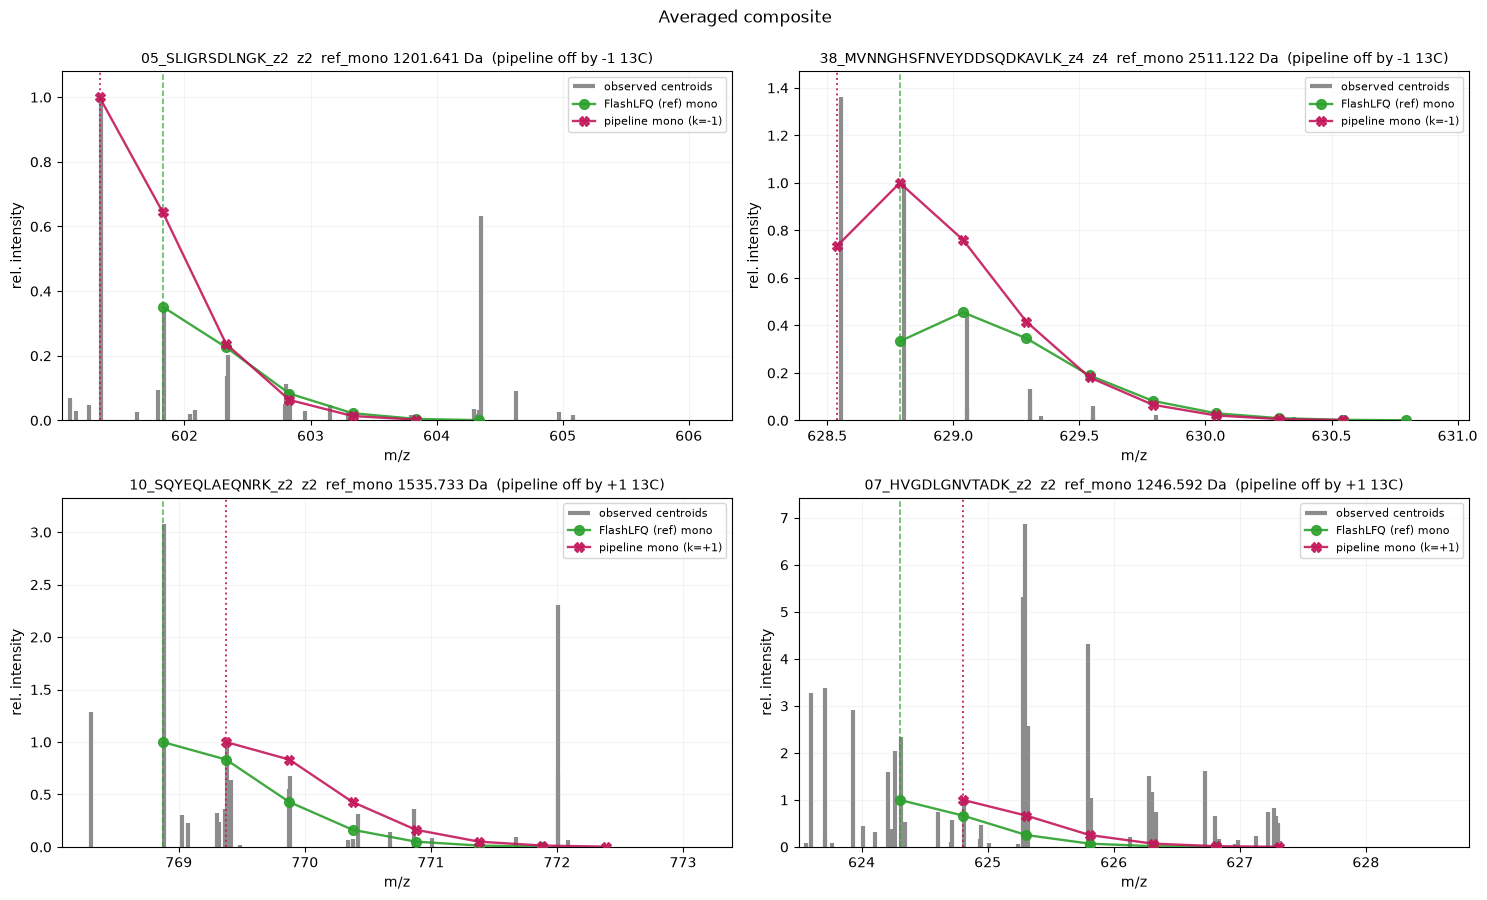

In [84]:
REF_C, PIPE_C, OBS_C = "#2ca02c", "#c2185b", "0.55"
PPM_TOL = 10.0
PPM_TOL_FALLBACK = 35.0
SCALE_MIN_REL_THEORY = 0.25

def _best_theory_scale(
    obs,
    pts,
    ppm_tol=PPM_TOL,
    ppm_tol_fallback=PPM_TOL_FALLBACK,
    min_rel_theory=SCALE_MIN_REL_THEORY,
):
    if not pts:
        fallback = max((i for _, i in obs), default=1.0) or 1.0
        return fallback, 1.0, False

    max_theo_w = max((theo_w for _, theo_w in pts), default=1.0) or 1.0
    min_theo_w = max_theo_w * min_rel_theory
    preferred = [(theo_mz, theo_w) for theo_mz, theo_w in pts if theo_w >= min_theo_w]

    def best_match(candidates, tol_ppm):
        ordered = sorted(candidates, key=lambda x: (-x[1], x[0]))
        for theo_mz, theo_w in ordered:
            if theo_w <= 0:
                continue
            tol = theo_mz * tol_ppm * 1e-6
            matched = [(obs_mz, obs_i) for obs_mz, obs_i in obs if abs(obs_mz - theo_mz) <= tol]
            if not matched:
                continue
            obs_mz, obs_i = max(matched, key=lambda x: (x[1], -abs(x[0] - theo_mz)))
            return obs_i, theo_w, obs_mz, theo_mz
        return None

    for candidates, tol_ppm in (
        (preferred, ppm_tol),
        (preferred, ppm_tol_fallback),
        (pts, ppm_tol),
        (pts, ppm_tol_fallback),
    ):
        best = best_match(candidates, tol_ppm)
        if best is not None:
            return best[0], best[1], True

    fallback = max((i for _, i in obs), default=1.0) or 1.0
    return fallback, 1.0, False

def plot_case(case, observed="observed_composite", extra_shifts=(), ax=None):
    m = meta[case]; z, sp, mono_mz, rk = m["z"], m["spacing"], m["mono_mz"], m["reported_k"]
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 5))
    xmin, xmax = mono_mz - 1.6*sp, mono_mz + 9*sp
    obs = [(mz, i) for mz, i in series[case][observed] if xmin <= mz <= xmax]

    curves = [(0, REF_C, "o", "FlashLFQ (ref) mono"),
              (rk, PIPE_C, "X", f"pipeline mono (k={rk:+d})")]
    for k in extra_shifts:
        curves.append((k, None, ".", f"k={k:+d}"))

    curve_data = []
    norm_base = None
    for k, color, marker, name in curves:
        pts = template(m["ref_mono"], z, k)
        pts = [(mz, w) for mz, w in pts if xmin-sp <= mz <= xmax+sp]
        matched_obs_i, matched_theo_w, found_match = _best_theory_scale(obs, pts)
        if norm_base is None or matched_obs_i > norm_base:
            norm_base = matched_obs_i
        curve_data.append((pts, color, marker, name, matched_obs_i, matched_theo_w, found_match))

    norm_base = norm_base or (max((i for _, i in obs), default=1.0) or 1.0)
    obs_ymax = 0.0
    for mz, i in obs:
        y = i / norm_base
        obs_ymax = max(obs_ymax, y)
        ax.vlines(mz, 0, y, color=OBS_C, lw=3, zorder=1)
    ax.vlines([], [], [], color=OBS_C, lw=3, label="observed centroids")

    theory_ymax = 0.0
    for pts, color, marker, name, matched_obs_i, matched_theo_w, found_match in curve_data:
        target_y = matched_obs_i / norm_base
        scaled_y = [w * target_y for _, w in pts]
        theory_ymax = max(theory_ymax, max(scaled_y, default=0.0))
        label = name if found_match else f"{name} (no match)"
        ax.plot([p[0] for p in pts], scaled_y, "-", marker=marker, ms=7, lw=1.7,
                alpha=.9, color=color, label=label, zorder=3)

    ax.axvline(mono_mz, color=REF_C, ls="--", lw=1.1, alpha=.8)
    ax.axvline(mono_mz + rk*sp, color=PIPE_C, ls=":", lw=1.4, alpha=.9)
    ymax = max(obs_ymax, theory_ymax, 1.0) * 1.08
    ax.set_xlim(xmin, xmax); ax.set_ylim(0, ymax)
    ax.set_title(f"{case}  z{z}  ref_mono {m['ref_mono']:.3f} Da  (pipeline off by {rk:+d} 13C)", fontsize=10)
    ax.set_xlabel("m/z"); ax.set_ylabel("rel. intensity")
    ax.legend(fontsize=8, loc="upper right"); ax.grid(True, alpha=.15)
    return ax

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for ax, case in zip(axes.flat, picked):
    plot_case(case, "observed_composite", ax=ax)
fig.suptitle("Averaged composite", y=.995); fig.tight_layout()

Same four, but the **single apex scan** instead of the averaged composite:

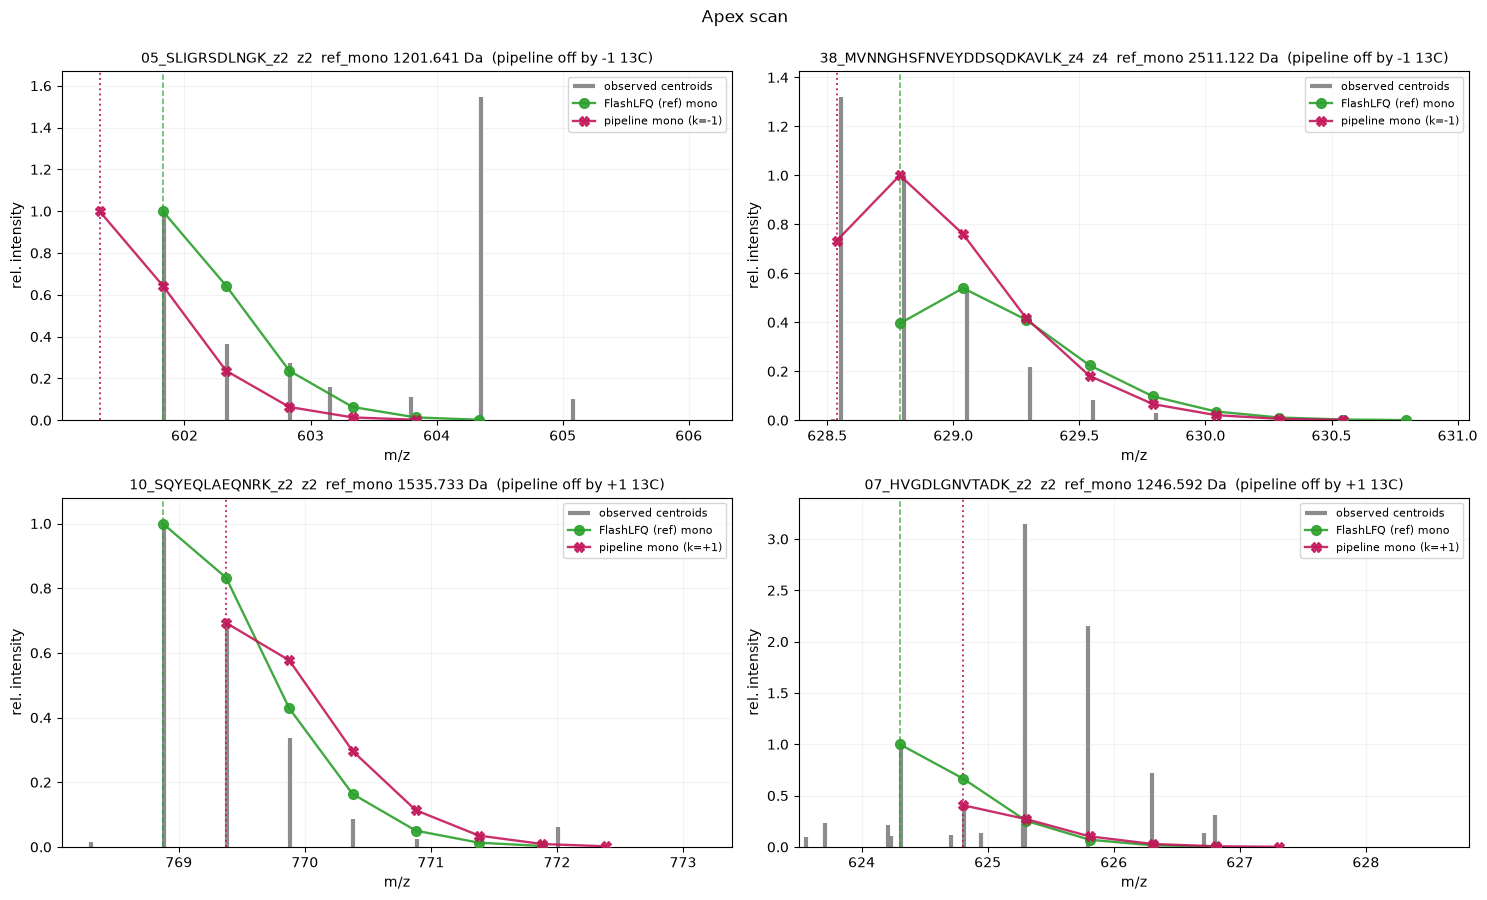

In [85]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for ax, case in zip(axes.flat, picked):
    plot_case(case, "observed_apex", ax=ax)
fig.suptitle("Apex scan", y=.995); fig.tight_layout()

## Elution explorer

`plot_elution(case)` shows every scan in the apex +-3 window as a small multiple, so you can see how
the envelope (and which peaks are present) changes across the peak. Watch the monoisotope peak appear
and disappear -- that per-scan instability is part of why the off-by-one happens.

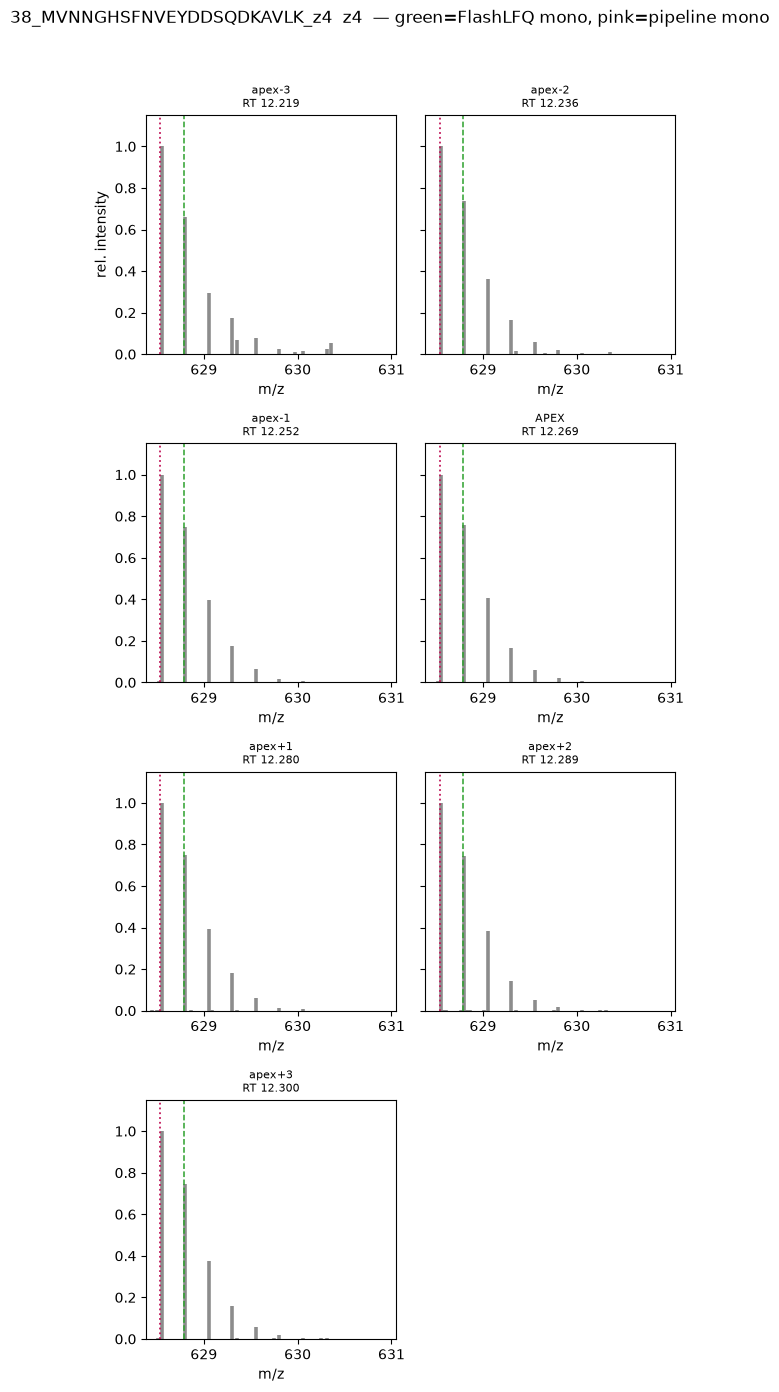

In [79]:
def plot_elution(case):
    m = meta[case]; z, sp, mono_mz, rk = m["z"], m["spacing"], m["mono_mz"], m["reported_k"]
    offs = sorted(scans[case])
    n = len(offs)
    rows = max(1, int(np.ceil(n / 2)))
    fig, axes = plt.subplots(rows, 2, figsize=(3.1*2, 3.4*rows), sharey=True)
    axes = np.atleast_1d(axes).ravel()
    xmin, xmax = mono_mz - 1.6*sp, mono_mz + 9*sp
    for ax, off in zip(axes, offs):
        pts = [(mz, i) for mz, i in scans[case][off] if xmin <= mz <= xmax]
        omax = max((i for _, i in pts), default=1.0) or 1.0
        for mz, i in pts:
            ax.vlines(mz, 0, i/omax, color=OBS_C, lw=2.6)
        ax.axvline(mono_mz, color=REF_C, ls="--", lw=1.1)
        ax.axvline(mono_mz + rk*sp, color=PIPE_C, ls=":", lw=1.3)
        ax.set_xlim(xmin, xmax); ax.set_ylim(0, 1.15)
        tag = "APEX" if off == 0 else f"apex{off:+d}"
        ax.set_title(f"{tag}\nRT {scan_rt[case][off]:.3f}", fontsize=8)
        ax.set_xlabel("m/z")
    for ax in axes[n:]:
        ax.set_visible(False)
    axes[0].set_ylabel("rel. intensity")
    fig.suptitle(f"{case}  z{z}  — green=FlashLFQ mono, pink=pipeline mono", y=1.02)
    fig.tight_layout()

plot_elution(picked[1])

## Free exploration

Pick a case and overlay whatever shifts you like:

In [ ]:
# Try an arbitrary set of shifts on any case:
plot_case("AVVQDPALKP(z3)", "observed_composite", extra_shifts=[-2, +1]);

In [ ]:
# Optional slider (only if ipywidgets is installed):
try:
    from ipywidgets import interact, Dropdown, SelectMultiple
    def _explore(case, observed):
        plot_case(case, observed); plt.show()
    interact(_explore,
             case=Dropdown(options=order, value=order[0]),
             observed=Dropdown(options=["observed_composite", "observed_apex"]))
except Exception as e:
    print("ipywidgets not available (%s) -- edit the cells above to explore manually." % e)